In [ ]:
import pandas as pd, yfinance as yf, pandas_datareader.data as web
import statsmodels.api as sm
sp = pd.read_html('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies')[0]
sp.columns= sp.columns.str.replace(' ','_').str.lower()

start = '2010-01-01'
end = '2025-03-12'
#Filter SP
sp = sp[sp['gics_sector'] != 'Financials']
sp = sp[sp['gics_sector'] != 'Real Estate']
# Calculate returns
sp_ret = yf.download(sp['symbol'].to_list(),
        start=start, end=end)['Close'].pct_change()[1:]

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  399 of 399 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['BF.B']: YFPricesMissingError('possibly delisted; no price data found  (1d 2010-01-01 -> 2025-03-12)')
<ipython-input-2-65cfb2f72cd6>:13: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  start=start, end=end)['Close'].pct_change()[1:]


In [ ]:
sp

,symbol,security,gics_sector,gics_sub-industry,headquarters_location,date_added,cik,founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989
...,...,...,...,...,...,...,...,...
498,XYL,Xylem Inc.,Industrials,Industrial Machinery & Supplies & Components,"White Plains, New York",2011-11-01,1524472,2011
499,YUM,Yum! Brands,Consumer Discretionary,Restaurants,"Louisville, Kentucky",1997-10-06,1041061,1997
500,ZBRA,Zebra Technologies,Information Technology,Electronic Equipment & Instruments,"Lincolnshire, Illinois",2019-12-23,877212,1969
501,ZBH,Zimmer Biomet,Health Care,Health Care Equipment,"Warsaw, Indiana",2001-08-07,1136869,1927


In [ ]:
sp_ret

Ticker,A,AAPL,ABBV,ABNB,ABT,ACN,ADBE,ADI,ADM,ADP,...,WMT,WST,WYNN,XEL,XOM,XYL,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-05,-0.010863,0.001729,NaN,NaN,-0.008079,0.006180,0.016446,-0.001579,0.005402,-0.005370,...,-0.009957,-0.012668,0.060819,-0.011860,0.003905,NaN,-0.003419,0.031656,-0.001744,NaN
2010-01-06,-0.003553,-0.015907,NaN,NaN,0.005554,0.010631,-0.002122,-0.001897,-0.002528,-0.002347,...,-0.002235,-0.009751,-0.013117,0.001920,0.008643,NaN,-0.007149,-0.000323,-0.007687,NaN
2010-01-07,-0.001296,-0.001848,NaN,NaN,0.008284,-0.000935,-0.019405,-0.007922,-0.010456,-0.000470,...,0.000560,0.003109,0.021356,-0.004312,-0.003142,NaN,-0.000288,0.022940,-0.025000,NaN
2010-01-08,-0.000325,0.006648,NaN,NaN,0.005112,-0.003978,-0.005422,0.005749,-0.012488,-0.001413,...,-0.005037,-0.000258,-0.007165,0.000482,-0.004012,NaN,0.000288,-0.021004,-0.003250,NaN
2010-01-11,0.000649,-0.008821,NaN,NaN,0.005086,-0.000940,-0.013083,-0.005716,0.000648,0.004479,...,0.016501,-0.004392,-0.003240,0.009619,0.011220,NaN,0.017281,0.022100,0.003261,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-05,0.028035,-0.000805,0.018194,0.008203,0.000945,0.007172,0.011681,0.014546,-0.000437,-0.009603,...,0.010635,0.022123,0.040987,-0.018563,-0.019528,0.018457,0.006060,0.007308,0.020408,-0.017069
2025-03-06,0.000316,-0.001739,-0.003734,-0.054776,-0.019098,-0.018435,-0.014316,-0.029198,0.049345,-0.025674,...,-0.013961,0.009586,-0.027352,-0.015568,0.020675,-0.005475,-0.000690,0.005442,-0.031053,0.001497
2025-03-07,0.001185,0.015893,0.016797,-0.002820,0.015250,0.000995,0.010387,0.013871,0.028714,0.013192,...,-0.030854,-0.005542,0.006010,0.005025,0.013009,0.012872,0.020532,0.025351,-0.006348,0.018655


In [ ]:
sp_ret1 = sp_ret.pct_change()[1:]

<ipython-input-5-302bd4a48d6c>:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  sp_ret1 = sp_ret.pct_change()[1:]


In [ ]:
sp_ret1

Ticker,A,AAPL,ABBV,ABNB,ABT,ACN,ADBE,ADI,ADM,ADP,...,WMT,WST,WYNN,XEL,XOM,XYL,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-06,-0.672889,-10.199655,NaN,NaN,-1.687402,0.720060,-1.129028,0.202039,-1.468045,-0.562895,...,-0.775516,-0.230300,-1.215668,-1.161892,1.213131,NaN,1.090749,-1.010192,3.407779,NaN
2010-01-07,-0.635186,-0.883799,NaN,NaN,0.491632,-1.087950,8.144190,3.174823,3.135845,-0.799567,...,-1.250502,-1.318829,-2.628136,-3.246047,-1.363543,NaN,-0.959703,-72.099289,2.252251,NaN
2010-01-08,-0.749601,-4.596693,NaN,NaN,-0.382892,3.254449,-0.720605,-1.725708,0.194256,2.002500,...,-9.995753,-1.083048,-1.335502,-1.111771,0.276753,NaN,-2.000288,-1.915622,-0.869989,NaN
2010-01-11,-3.000351,-2.326930,NaN,NaN,-0.005066,-0.763733,1.413071,-1.994284,-1.051919,-4.170878,...,-4.275889,16.012958,-0.547781,18.957180,-3.796974,NaN,58.968474,-2.052189,-2.003261,NaN
2010-01-12,-19.489710,0.289509,NaN,NaN,-1.568568,5.754559,0.161022,6.264026,-17.493665,-2.571925,...,-0.418707,-0.172622,-2.368099,0.238162,-1.443731,NaN,0.097713,-1.871248,-1.332257,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-05,-2.083081,-0.908725,-2.034322,1.628155,-1.050189,2.132048,-0.030514,-3.433642,-0.973247,-0.411550,...,-1.396133,-3.026137,-2.991805,-0.286253,8.564922,-1.973742,-0.357422,-1.554073,-1.702022,3.620198
2025-03-06,-0.988722,1.159799,-1.205259,-7.677959,-21.210949,-3.570269,-2.225608,-3.007270,-114.046866,1.673506,...,-2.312773,-0.566702,-1.667325,-0.161352,-2.058771,-1.296649,-1.113895,-0.255444,-2.521583,-1.087704
2025-03-07,2.748576,-10.137776,-5.497839,-0.948524,-1.798518,-1.053953,-1.725558,-1.475064,-0.418096,-1.513822,...,1.209950,-1.578167,-1.219719,-1.322779,-0.370810,-3.350912,-30.747679,3.658859,-0.795559,11.461326


In [ ]:
sp_ret_pivot = sp_ret.reset_index().melt(id_vars='Date', var_name='symbol', value_name='return')

In [ ]:
sp_ret_pivot

,Date,symbol,return
0,2010-01-05,A,-0.010863
1,2010-01-06,A,-0.003553
2,2010-01-07,A,-0.001296
3,2010-01-08,A,-0.000325
4,2010-01-11,A,0.000649
...,...,...,...
1523776,2025-03-05,ZTS,-0.017069
1523777,2025-03-06,ZTS,0.001497
1523778,2025-03-07,ZTS,0.018655
1523779,2025-03-10,ZTS,0.008394


In [ ]:
# Add sector information
returns = pd.merge(sp_ret_pivot, sp[['symbol', 'gics_sector']], on='symbol')

# Calculate the correlation matrix
corr_matrix = returns.pivot_table(index='Date', columns='gics_sector',
                                  values='return', aggfunc='mean').corr()

In [ ]:
returns

,Date,symbol,return,gics_sector
0,2010-01-05,A,-0.010863,Health Care
1,2010-01-06,A,-0.003553,Health Care
2,2010-01-07,A,-0.001296,Health Care
3,2010-01-08,A,-0.000325,Health Care
4,2010-01-11,A,0.000649,Health Care
...,...,...,...,...
1523776,2025-03-05,ZTS,-0.017069,Health Care
1523777,2025-03-06,ZTS,0.001497,Health Care
1523778,2025-03-07,ZTS,0.018655,Health Care
1523779,2025-03-10,ZTS,0.008394,Health Care


In [ ]:
corr_matrix

gics_sector,Communication Services,Consumer Discretionary,Consumer Staples,Energy,Health Care,Industrials,Information Technology,Materials,Utilities
gics_sector,,,,,,,,,
Communication Services,1.000000,0.841798,0.669523,0.602170,0.772758,0.832429,0.821898,0.775296,0.530673
Consumer Discretionary,0.841798,1.000000,0.666376,0.645783,0.766710,0.897883,0.836606,0.828424,0.527885
Consumer Staples,0.669523,0.666376,1.000000,0.488840,0.722452,0.714682,0.601126,0.674144,0.701020
Energy,0.602170,0.645783,0.488840,1.000000,0.549659,0.690190,0.581891,0.739214,0.439000
Health Care,0.772758,0.766710,0.722452,0.549659,1.000000,0.815636,0.791824,0.752807,0.588588
Industrials,0.832429,0.897883,0.714682,0.690190,0.815636,1.000000,0.855177,0.897055,0.595031
Information Technology,0.821898,0.836606,0.601126,0.581891,0.791824,0.855177,1.000000,0.780874,0.473729
Materials,0.775296,0.828424,0.674144,0.739214,0.752807,0.897055,0.780874,1.000000,0.562336
Utilities,0.530673,0.527885,0.701020,0.439000,0.588588,0.595031,0.473729,0.562336,1.000000


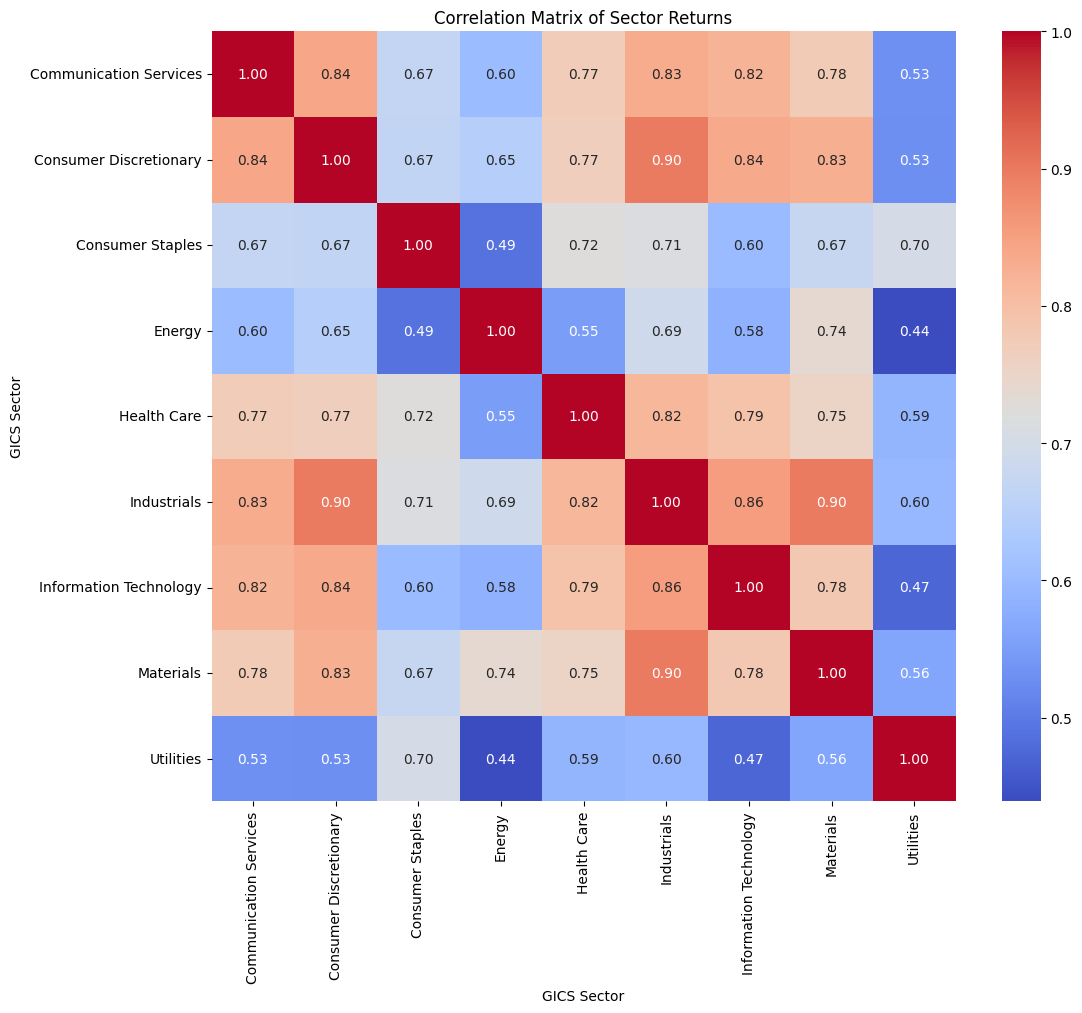

In [ ]:
# prompt: Please generate a matplotlib heatmap of corr_matrix and make sure each is labelled

import matplotlib.pyplot as plt
import seaborn as sns

# Assuming corr_matrix is already calculated as in your provided code

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Sector Returns')
plt.xlabel('GICS Sector')
plt.ylabel('GICS Sector')
plt.show()


In [ ]:
#Selecting Communication Services and Utilities
#Get returns of stocks and S&P500 and then merge them
sp1 = sp[sp['gics_sector']=='Utilities']
sp2 = sp[sp['gics_sector'] == 'Communication Services']
sp_ret1 = yf.download(sp1['symbol'].to_list(),
        start=start, end=end)['Close'].resample('M').last().pct_change()[1:]
sp_ret2 = yf.download(sp2['symbol'].to_list(),
        start=start, end=end)['Close'].resample('M').last().pct_change()[1:]

sp_ret = pd.concat([sp_ret1, sp_ret2], axis=1)

[*********************100%***********************]  31 of 31 completed
<ipython-input-13-fc887a92c032>:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  start=start, end=end)['Close'].resample('M').last().pct_change()[1:]
[*********************100%***********************]  22 of 22 completed
<ipython-input-13-fc887a92c032>:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  start=start, end=end)['Close'].resample('M').last().pct_change()[1:]


In [ ]:
sp1[['symbol','security','gics_sector']]

,symbol,security,gics_sector
7,AES,AES Corporation,Utilities
17,LNT,Alliant Energy,Utilities
24,AEE,Ameren,Utilities
25,AEP,American Electric Power,Utilities
29,AWK,American Water Works,Utilities
48,ATO,Atmos Energy,Utilities
96,CNP,CenterPoint Energy,Utilities
113,CMS,CMS Energy,Utilities
120,ED,Consolidated Edison,Utilities
122,CEG,Constellation Energy,Utilities


In [ ]:
sp_ret

Ticker,AEE,AEP,AES,ATO,AWK,CEG,CMS,CNP,D,DTE,...,NFLX,NWS,NWSA,OMC,PARA,T,TMUS,TTWO,VZ,WBD
Date,,,,,,,,,,,,,,,,,,,,,
2010-02-28,-0.032877,-0.017754,-0.074426,0.006246,0.030870,NaN,0.016519,-0.027143,0.026256,0.032826,...,0.061044,NaN,NaN,0.037394,0.004640,-0.021687,0.095915,0.036638,-0.016656,0.050236
2010-03-31,0.071344,0.016657,-0.059025,0.040422,-0.022461,NaN,0.012442,0.073243,0.082127,0.039197,...,0.116427,NaN,NaN,0.065461,0.076793,0.041515,0.147488,0.025988,0.072244,0.084751
2010-04-30,-0.004601,0.003511,0.049091,0.035352,0.000919,NaN,0.051747,0.000000,0.016784,0.080045,...,0.341199,NaN,NaN,0.099201,0.162841,0.030290,0.077684,0.099291,-0.053940,0.146197
2010-05-31,-0.050077,-0.056344,-0.110052,-0.071719,-0.057011,NaN,-0.088686,-0.038307,-0.056933,-0.055221,...,0.123862,NaN,NaN,-0.110408,-0.101789,-0.067536,0.178244,0.066359,-0.047750,-0.027627
2010-06-30,-0.020436,0.010638,-0.100293,-0.002950,0.012783,NaN,-0.002043,-0.033774,-0.005647,0.013330,...,-0.022492,NaN,NaN,-0.091310,-0.108627,-0.004527,-0.088988,-0.222126,0.018168,-0.051779
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-30,0.083573,0.021098,-0.200833,0.096718,-0.002811,-0.022808,0.009068,0.112036,-0.001935,0.012558,...,0.172983,0.105028,0.077064,0.037822,-0.008227,0.027507,0.110551,0.164853,0.052457,0.289053
2024-12-31,-0.048634,-0.076407,-0.013037,-0.079633,-0.090916,-0.128040,-0.043896,-0.027284,-0.083234,-0.031284,...,0.005086,-0.051730,-0.061669,-0.172574,-0.031629,-0.016839,-0.106139,-0.022826,-0.098105,0.008588
2025-01-31,0.056765,0.066464,-0.131740,0.023264,0.001205,0.340932,-0.009752,0.026473,0.032120,-0.007205,...,0.095858,0.040092,0.021060,0.008717,0.040153,0.055389,0.055452,0.007768,0.002450,-0.012299


In [ ]:
# Get risk free rate of return
rf = web.DataReader('TB3MS', 'fred', start=start, end=end).\
pipe(lambda x: (1 + (x / 100)) ** (1 / 12) - 1).resample('M').last()

<ipython-input-16-46480f14917a>:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pipe(lambda x: (1 + (x / 100)) ** (1 / 12) - 1).resample('M').last()


In [ ]:
# Download ^GSPC ret and merge with sp_ret file
index_ret = yf.download('^GSPC',start=start, end=end)['Close'].resample('M').last().pct_change()[1:]

[*********************100%***********************]  1 of 1 completed
<ipython-input-17-65146df17136>:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  index_ret = yf.download('^GSPC',start=start, end=end)['Close'].resample('M').last().pct_change()[1:]


In [ ]:
sp_index = pd.merge(sp_ret, index_ret,left_index=True,right_index=True, how = 'inner').\
rename(columns = {'Close': 'sp_500'})

In [ ]:
sp_index

Ticker,AEE,AEP,AES,ATO,AWK,CEG,CMS,CNP,D,DTE,...,NWS,NWSA,OMC,PARA,T,TMUS,TTWO,VZ,WBD,^GSPC
Date,,,,,,,,,,,,,,,,,,,,,
2010-02-28,-0.032877,-0.017754,-0.074426,0.006246,0.030870,NaN,0.016519,-0.027143,0.026256,0.032826,...,NaN,NaN,0.037394,0.004640,-0.021687,0.095915,0.036638,-0.016656,0.050236,0.028514
2010-03-31,0.071344,0.016657,-0.059025,0.040422,-0.022461,NaN,0.012442,0.073243,0.082127,0.039197,...,NaN,NaN,0.065461,0.076793,0.041515,0.147488,0.025988,0.072244,0.084751,0.058796
2010-04-30,-0.004601,0.003511,0.049091,0.035352,0.000919,NaN,0.051747,0.000000,0.016784,0.080045,...,NaN,NaN,0.099201,0.162841,0.030290,0.077684,0.099291,-0.053940,0.146197,0.014759
2010-05-31,-0.050077,-0.056344,-0.110052,-0.071719,-0.057011,NaN,-0.088686,-0.038307,-0.056933,-0.055221,...,NaN,NaN,-0.110408,-0.101789,-0.067536,0.178244,0.066359,-0.047750,-0.027627,-0.081976
2010-06-30,-0.020436,0.010638,-0.100293,-0.002950,0.012783,NaN,-0.002043,-0.033774,-0.005647,0.013330,...,NaN,NaN,-0.091310,-0.108627,-0.004527,-0.088988,-0.222126,0.018168,-0.051779,-0.053882
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-30,0.083573,0.021098,-0.200833,0.096718,-0.002811,-0.022808,0.009068,0.112036,-0.001935,0.012558,...,0.105028,0.077064,0.037822,-0.008227,0.027507,0.110551,0.164853,0.052457,0.289053,0.057301
2024-12-31,-0.048634,-0.076407,-0.013037,-0.079633,-0.090916,-0.128040,-0.043896,-0.027284,-0.083234,-0.031284,...,-0.051730,-0.061669,-0.172574,-0.031629,-0.016839,-0.106139,-0.022826,-0.098105,0.008588,-0.024990
2025-01-31,0.056765,0.066464,-0.131740,0.023264,0.001205,0.340932,-0.009752,0.026473,0.032120,-0.007205,...,0.040092,0.021060,0.008717,0.040153,0.055389,0.055452,0.007768,0.002450,-0.012299,0.027016


In [ ]:
sp_index.rename(columns = {'^GSPC': 'sp_500'}, inplace = True)

In [ ]:
sp_index

Ticker,AEE,AEP,AES,ATO,AWK,CEG,CMS,CNP,D,DTE,...,NWS,NWSA,OMC,PARA,T,TMUS,TTWO,VZ,WBD,sp_500
Date,,,,,,,,,,,,,,,,,,,,,
2010-02-28,-0.032877,-0.017754,-0.074426,0.006246,0.030870,NaN,0.016519,-0.027143,0.026256,0.032826,...,NaN,NaN,0.037394,0.004640,-0.021687,0.095915,0.036638,-0.016656,0.050236,0.028514
2010-03-31,0.071344,0.016657,-0.059025,0.040422,-0.022461,NaN,0.012442,0.073243,0.082127,0.039197,...,NaN,NaN,0.065461,0.076793,0.041515,0.147488,0.025988,0.072244,0.084751,0.058796
2010-04-30,-0.004601,0.003511,0.049091,0.035352,0.000919,NaN,0.051747,0.000000,0.016784,0.080045,...,NaN,NaN,0.099201,0.162841,0.030290,0.077684,0.099291,-0.053940,0.146197,0.014759
2010-05-31,-0.050077,-0.056344,-0.110052,-0.071719,-0.057011,NaN,-0.088686,-0.038307,-0.056933,-0.055221,...,NaN,NaN,-0.110408,-0.101789,-0.067536,0.178244,0.066359,-0.047750,-0.027627,-0.081976
2010-06-30,-0.020436,0.010638,-0.100293,-0.002950,0.012783,NaN,-0.002043,-0.033774,-0.005647,0.013330,...,NaN,NaN,-0.091310,-0.108627,-0.004527,-0.088988,-0.222126,0.018168,-0.051779,-0.053882
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-30,0.083573,0.021098,-0.200833,0.096718,-0.002811,-0.022808,0.009068,0.112036,-0.001935,0.012558,...,0.105028,0.077064,0.037822,-0.008227,0.027507,0.110551,0.164853,0.052457,0.289053,0.057301
2024-12-31,-0.048634,-0.076407,-0.013037,-0.079633,-0.090916,-0.128040,-0.043896,-0.027284,-0.083234,-0.031284,...,-0.051730,-0.061669,-0.172574,-0.031629,-0.016839,-0.106139,-0.022826,-0.098105,0.008588,-0.024990
2025-01-31,0.056765,0.066464,-0.131740,0.023264,0.001205,0.340932,-0.009752,0.026473,0.032120,-0.007205,...,0.040092,0.021060,0.008717,0.040153,0.055389,0.055452,0.007768,0.002450,-0.012299,0.027016


In [ ]:
all_data = pd.merge(sp_index,rf, how='inner', left_index=True, right_index=True)

In [ ]:
all_data

,AEE,AEP,AES,ATO,AWK,CEG,CMS,CNP,D,DTE,...,NWSA,OMC,PARA,T,TMUS,TTWO,VZ,WBD,sp_500,TB3MS
2010-02-28,-0.032877,-0.017754,-0.074426,0.006246,0.030870,NaN,0.016519,-0.027143,0.026256,0.032826,...,NaN,0.037394,0.004640,-0.021687,0.095915,0.036638,-0.016656,0.050236,0.028514,0.000092
2010-03-31,0.071344,0.016657,-0.059025,0.040422,-0.022461,NaN,0.012442,0.073243,0.082127,0.039197,...,NaN,0.065461,0.076793,0.041515,0.147488,0.025988,0.072244,0.084751,0.058796,0.000125
2010-04-30,-0.004601,0.003511,0.049091,0.035352,0.000919,NaN,0.051747,0.000000,0.016784,0.080045,...,NaN,0.099201,0.162841,0.030290,0.077684,0.099291,-0.053940,0.146197,0.014759,0.000133
2010-05-31,-0.050077,-0.056344,-0.110052,-0.071719,-0.057011,NaN,-0.088686,-0.038307,-0.056933,-0.055221,...,NaN,-0.110408,-0.101789,-0.067536,0.178244,0.066359,-0.047750,-0.027627,-0.081976,0.000133
2010-06-30,-0.020436,0.010638,-0.100293,-0.002950,0.012783,NaN,-0.002043,-0.033774,-0.005647,0.013330,...,NaN,-0.091310,-0.108627,-0.004527,-0.088988,-0.222126,0.018168,-0.051779,-0.053882,0.000100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-31,-0.004002,-0.037524,-0.177966,0.000505,-0.055594,0.011307,-0.014441,0.003739,0.030109,-0.032630,...,0.023282,-0.023116,0.030132,0.037700,0.081411,0.052111,-0.047257,-0.014545,-0.009897,0.003683
2024-11-30,0.083573,0.021098,-0.200833,0.096718,-0.002811,-0.022808,0.009068,0.112036,-0.001935,0.012558,...,0.077064,0.037822,-0.008227,0.027507,0.110551,0.164853,0.052457,0.289053,0.057301,0.003611
2024-12-31,-0.048634,-0.076407,-0.013037,-0.079633,-0.090916,-0.128040,-0.043896,-0.027284,-0.083234,-0.031284,...,-0.061669,-0.172574,-0.031629,-0.016839,-0.106139,-0.022826,-0.098105,0.008588,-0.024990,0.003491
2025-01-31,0.056765,0.066464,-0.131740,0.023264,0.001205,0.340932,-0.009752,0.026473,0.032120,-0.007205,...,0.021060,0.008717,0.040153,0.055389,0.055452,0.007768,0.002450,-0.012299,0.027016,0.003442


In [ ]:
# Calculate excess rate by subtracting all returns from 3-month T-bill
excess_ret = all_data.sub(all_data['TB3MS'], axis=0).drop(columns=['TB3MS'])

In [ ]:
#Calculate Average annual Sharpe ratios
annual_sharpe_ratio = excess_ret.groupby(excess_ret.index.year).agg('mean')/excess_ret.groupby(excess_ret.index.year).agg('std')

avg_annual_sharpe_ratio = annual_sharpe_ratio.agg('mean').to_frame()

In [ ]:
avg_annual_sharpe_ratio


,0
AEE,0.489373
AEP,0.518646
AES,0.055046
ATO,0.330773
AWK,0.338855
CEG,0.386001
CMS,0.297862
CNP,0.274799
D,1.952161
DTE,0.282461


In [ ]:
#Merge with "sp" file to add sector information
merged_df = avg_annual_sharpe_ratio.merge(sp[['symbol', 'gics_sector']],
                                          left_index=True, right_on='symbol', how='left').\
    rename(columns={0:'Sharpe'}).reset_index()

In [ ]:
merged_df

,index,Sharpe,symbol,gics_sector
0,24.0,0.489373,AEE,Utilities
1,25.0,0.518646,AEP,Utilities
2,7.0,0.055046,AES,Utilities
3,48.0,0.330773,ATO,Utilities
4,29.0,0.338855,AWK,Utilities
5,122.0,0.386001,CEG,Utilities
6,113.0,0.297862,CMS,Utilities
7,96.0,0.274799,CNP,Utilities
8,151.0,1.952161,D,Utilities
9,156.0,0.282461,DTE,Utilities


In [ ]:
merged_df.drop(columns=['index'])

,Sharpe,symbol,gics_sector
0,0.489373,AEE,Utilities
1,0.518646,AEP,Utilities
2,0.055046,AES,Utilities
3,0.330773,ATO,Utilities
4,0.338855,AWK,Utilities
5,0.386001,CEG,Utilities
6,0.297862,CMS,Utilities
7,0.274799,CNP,Utilities
8,1.952161,D,Utilities
9,0.282461,DTE,Utilities


In [ ]:
top_sharpe_comms = merged_df.query(" gics_sector == 'Communication Services' ").nlargest(5,'Sharpe')
top_sharpe_util = merged_df.query(" gics_sector == 'Utilities' ").nlargest(5,'Sharpe')
top_sharpe = pd.concat([top_sharpe_comms, top_sharpe_util])


In [ ]:
top_sharpe

,index,Sharpe,symbol,gics_sector
47,363.0,0.968205,PARA,Communication Services
45,336.0,0.645627,NWSA,Communication Services
35,203.0,0.430340,FOX,Communication Services
49,432.0,0.361292,TMUS,Communication Services
36,202.0,0.348371,FOXA,Communication Services
8,151.0,1.952161,D,Utilities
14,169.0,0.628050,ETR,Utilities
1,25.0,0.518646,AEP,Utilities
0,24.0,0.489373,AEE,Utilities
29,487.0,0.440154,WEC,Utilities


In [ ]:
top_sharpe.drop(columns=['index'])

,Sharpe,symbol,gics_sector
47,0.968205,PARA,Communication Services
45,0.645627,NWSA,Communication Services
35,0.430340,FOX,Communication Services
49,0.361292,TMUS,Communication Services
36,0.348371,FOXA,Communication Services
8,1.952161,D,Utilities
14,0.628050,ETR,Utilities
1,0.518646,AEP,Utilities
0,0.489373,AEE,Utilities
29,0.440154,WEC,Utilities


In [ ]:
selected = top_sharpe_comms['symbol'].tolist() + ['sp_500'] + top_sharpe_util['symbol'].tolist()
selected_ret = excess_ret.loc[:, excess_ret.columns.isin(selected)]

In [ ]:
selected_ret

,AEE,AEP,D,ETR,WEC,FOX,FOXA,NWSA,PARA,TMUS,sp_500
2010-02-28,-0.032969,-0.017846,0.026164,0.015420,-0.002214,NaN,NaN,NaN,0.004548,0.095823,0.028422
2010-03-31,0.071219,0.016532,0.082002,0.070692,0.020111,NaN,NaN,NaN,0.076669,0.147363,0.058672
2010-04-30,-0.004735,0.003378,0.016651,-0.000871,0.062607,NaN,NaN,NaN,0.162707,0.077550,0.014626
2010-05-31,-0.050210,-0.056478,-0.057066,-0.055970,-0.059768,NaN,NaN,NaN,-0.101922,0.178111,-0.082109
2010-06-30,-0.020536,0.010538,-0.005747,-0.046056,0.035410,NaN,NaN,NaN,-0.108727,-0.089088,-0.053982
...,...,...,...,...,...,...,...,...,...,...,...
2024-10-31,-0.007685,-0.041207,0.026426,0.172368,-0.010441,0.000441,-0.011479,0.019599,0.026449,0.077728,-0.013580
2024-11-30,0.079962,0.017488,-0.005546,0.021862,0.063297,0.144490,0.118294,0.073453,-0.011837,0.106940,0.053691
2024-12-31,-0.052125,-0.079898,-0.086725,-0.032497,-0.072862,0.019089,0.027494,-0.065160,-0.035120,-0.109630,-0.028481
2025-01-31,0.053322,0.063022,0.028678,0.065932,0.052066,0.059085,0.050078,0.017618,0.036711,0.052010,0.023574


In [ ]:
#Calculate beta and create a dataframe showing all values of beta
beta_df = pd.DataFrame(columns=['symbol', 'beta'])

for i in selected_ret:
    X = selected_ret[['sp_500']]
    x = sm.add_constant(X)
    y = selected_ret[i]

    # Fit the OLS model
    model = sm.OLS(y, x).fit()

    # Get the beta value (coefficient of 'index_excess')
    beta = model.params['sp_500']

    # Append the stock name and beta value to beta_df
    beta_df = pd.concat([beta_df, pd.DataFrame({'symbol': [i], 'beta': [beta]})], ignore_index=True)

<ipython-input-35-0b8fc7a98532>:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  beta_df = pd.concat([beta_df, pd.DataFrame({'symbol': [i], 'beta': [beta]})], ignore_index=True)


In [ ]:
beta_df

,symbol,beta
0,AEE,0.372055
1,AEP,0.397227
2,D,0.433553
3,ETR,0.513114
4,WEC,0.303881
5,FOX,NaN
6,FOXA,NaN
7,NWSA,NaN
8,PARA,1.633244
9,TMUS,0.655869


In [ ]:
# Add Sharpe information
top_sharpe_beta = pd.merge(top_sharpe,beta_df, how='inner',on='symbol')


In [ ]:
top_sharpe_beta

,index,Sharpe,symbol,gics_sector,beta
0,363.0,0.968205,PARA,Communication Services,1.633244
1,336.0,0.645627,NWSA,Communication Services,NaN
2,203.0,0.430340,FOX,Communication Services,NaN
3,432.0,0.361292,TMUS,Communication Services,0.655869
4,202.0,0.348371,FOXA,Communication Services,NaN
5,151.0,1.952161,D,Utilities,0.433553
6,169.0,0.628050,ETR,Utilities,0.513114
7,25.0,0.518646,AEP,Utilities,0.397227
8,24.0,0.489373,AEE,Utilities,0.372055
9,487.0,0.440154,WEC,Utilities,0.303881


In [ ]:
top_sharpe_beta.drop(columns=['index'])

,Sharpe,symbol,gics_sector,beta
0,0.968205,PARA,Communication Services,1.633244
1,0.645627,NWSA,Communication Services,NaN
2,0.430340,FOX,Communication Services,NaN
3,0.361292,TMUS,Communication Services,0.655869
4,0.348371,FOXA,Communication Services,NaN
5,1.952161,D,Utilities,0.433553
6,0.628050,ETR,Utilities,0.513114
7,0.518646,AEP,Utilities,0.397227
8,0.489373,AEE,Utilities,0.372055
9,0.440154,WEC,Utilities,0.303881


In [ ]:
# Selected top 5 Sharpe; then within that top 5 - selected smallest 3 beta
top_list = top_sharpe_beta.nlargest(5,['Sharpe']).nsmallest(3,['beta']).reset_index()


In [ ]:
top_list

,level_0,index,Sharpe,symbol,gics_sector,beta
0,7,25.0,0.518646,AEP,Utilities,0.397227
1,5,151.0,1.952161,D,Utilities,0.433553
2,6,169.0,0.628050,ETR,Utilities,0.513114


In [ ]:
# Get stock prices of selected 3 stocks and S&P500 - then merge
top_list_price = yf.download(top_list['symbol'].to_list(),start=start, end=end)['Close']


[*********************100%***********************]  3 of 3 completed


In [ ]:
sp500 = yf.download('^GSPC',start=start, end=end)['Close']


[*********************100%***********************]  1 of 1 completed


In [ ]:
df = pd.merge(top_list_price,sp500,left_index=True,
                              right_index=True,how='inner')

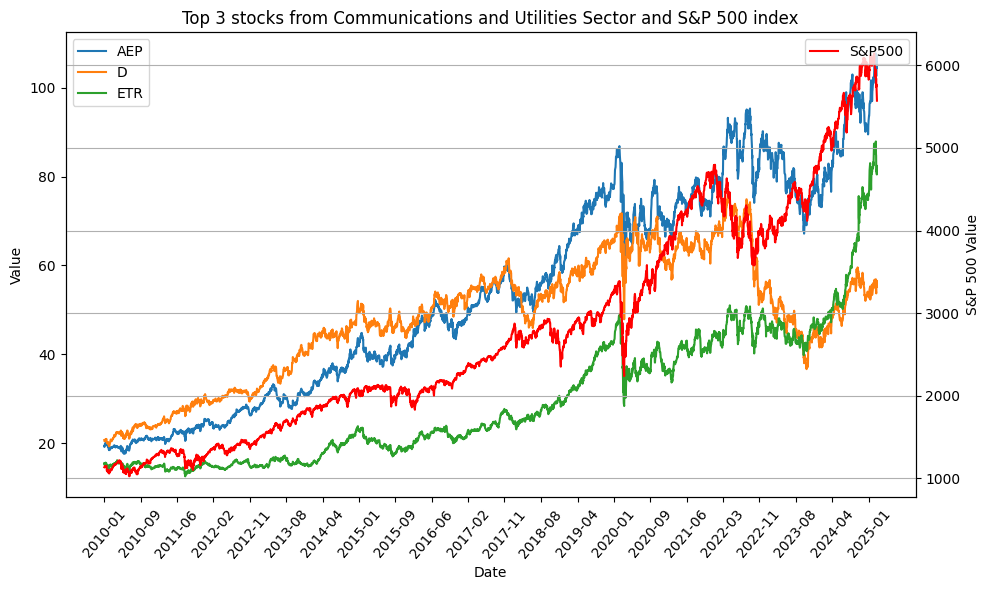

In [ ]:
# Show a time series plot of prices of 2 stocks and S&P 500 - 2 stocks in primaty axis and S&P500 in secondary axis
import matplotlib.pyplot as plt

# Create figure and axis objects
# width to 10 inches and the height to 6 inches
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot two lines on the primary y-axis
for column in df.columns[:-1]:
    ax1.plot(df.index, df[column], label=column)

# Set x-axis ticks with a 6-month gap
ax1.set_xticks(df.index[::180])
ax1.set_xticklabels(df.index.strftime('%Y-%m')[::180], rotation=50)

# Add labels and legend for primary y-axis
ax1.set_xlabel('Date')
ax1.set_ylabel('Value')
ax1.set_title('Top 3 stocks from Communications and Utilities Sector and S&P 500 index')
ax1.legend()

# Create secondary y-axis for "sp500" column
ax2 = ax1.twinx()
ax2.plot(df.index, df['^GSPC'], color='r', label='S&P500')
ax2.set_ylabel('S&P 500 Value')
ax2.legend(loc='upper right')

# Show plot
plt.grid(True)
plt.tight_layout()
plt.show()